# Laboratorio L12 - Prevedere un numero: la regressione lineare

B.6 - Data science e Machine Learning: dai dati ai modelli

File necessari: `pinguini.csv`, `tragitti_puliti.csv` (o il file pulito della classe).

Dati: Palmer Penguins, Horst AM, Hill AP, Gorman KB (2020), licenza CC0, https://allisonhorst.github.io/palmerpenguins/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def controlla(condizione, suggerimento="Non ancora: rileggere la consegna."):
    """Stampa un riscontro immediato sull'esercizio."""
    print("Corretto." if condizione else suggerimento)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

pinguini = pd.read_csv("pinguini.csv").dropna()      # solo pinguini con tutti i dati
print(len(pinguini), "pinguini")

333 pinguini


## 1. Una retta per la massa (esercizio 1)

Caratteristica: lunghezza della pinna. Etichetta: massa. La divisione in addestramento e verifica è la stessa di L10 (non serve `stratify`: l'etichetta è un numero).

- `LinearRegression()`: modello di regressione lineare
- dopo `fit`: `coef_` contiene la pendenza (una per ogni caratteristica), `intercept_` l'intercetta

In [2]:
X = pinguini[["pinna_lunghezza_mm"]]
y = pinguini["massa_g"]
X_add, X_ver, y_add, y_ver = train_test_split(X, y, test_size=0.25, random_state=42)

retta = LinearRegression().fit(X_add, y_add)
pendenza = retta.coef_[0]
intercetta = retta.intercept_
print(f"massa = {pendenza:.1f} x pinna + ({intercetta:.1f})")

massa = 50.0 x pinna + (-5848.7)


**Domanda**: che cosa significa la pendenza, in grammi e millimetri? L'intercetta ha un significato fisico?

Risposta:

Completare: usare la retta per prevedere a mano la massa di un pinguino con pinna di 200 mm (massa = pendenza x 200 + intercetta), poi confrontare con `predict`.

In [3]:
a_mano = pendenza * 200 + intercetta
con_predict = retta.predict(pd.DataFrame({"pinna_lunghezza_mm": [200]}))[0]
print(round(a_mano, 1), round(con_predict, 1))
controlla(abs(a_mano - con_predict) < 1e-6)

4155.4 4155.4
Corretto.


## 2. Grafico e residui (esercizio 2)

Residuo: massa vera - massa prevista. Positivo se il pinguino pesa più di quanto previsto.

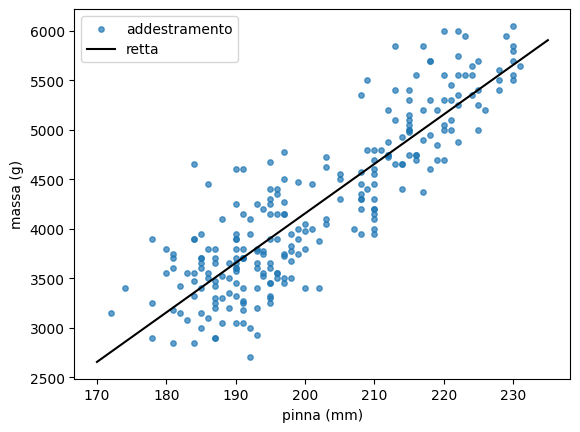

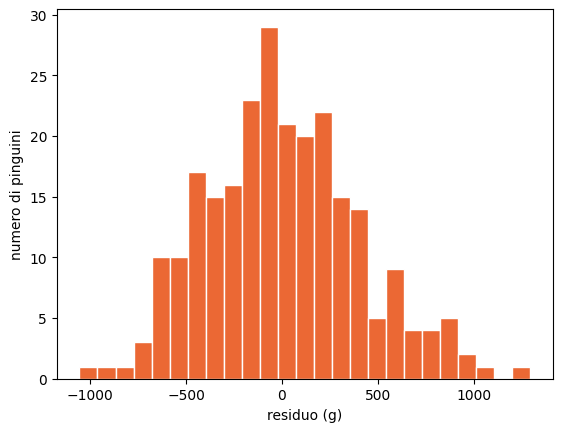

media dei residui: 0.0


In [4]:
plt.scatter(X_add["pinna_lunghezza_mm"], y_add, s=15, alpha=0.7, label="addestramento")
xs = np.array([170, 235])
plt.plot(xs, pendenza * xs + intercetta, color="black", label="retta")
plt.xlabel("pinna (mm)"); plt.ylabel("massa (g)"); plt.legend()
plt.show()

residui = y_add - retta.predict(X_add)
plt.hist(residui, bins=25, color="#eb6834", edgecolor="white")
plt.xlabel("residuo (g)"); plt.ylabel("numero di pinguini")
plt.show()
print("media dei residui:", round(residui.mean(), 6))

## 3. Errore sulla verifica e baseline (esercizio 2)

- `mean_absolute_error` (MAE): media dei valori assoluti dei residui, in grammi
- RMSE: radice della media dei quadrati dei residui; `mean_squared_error(...) ** 0.5`; pesa di più gli errori grandi
- baseline per la regressione: prevedere sempre la media delle masse di addestramento

In [5]:
previsti = retta.predict(X_ver)
mae = mean_absolute_error(y_ver, previsti)
rmse = mean_squared_error(y_ver, previsti) ** 0.5
mae_base = mean_absolute_error(y_ver, np.full(len(y_ver), y_add.mean()))
print(f"MAE retta: {mae:.1f} g   RMSE retta: {rmse:.1f} g   MAE baseline: {mae_base:.1f} g")

MAE retta: 289.7 g   RMSE retta: 370.7 g   MAE baseline: 642.8 g


**Domanda**: di quanto sbaglia in media la retta? Quanto è migliore della baseline?

Risposta:

## 4. Più caratteristiche e caratteristiche qualitative (esercizio 3)

La regressione lineare lavora con numeri. Una variabile qualitativa si trasforma in colonne di 0 e 1 (codifica one-hot):

- `pd.get_dummies(tabella, drop_first=True, dtype=int)`: una colonna per ogni categoria, esclusa la prima (che resta il riferimento)
- `specie_Chinstrap` vale 1 per i Chinstrap e 0 altrimenti; lo stesso per `specie_Gentoo`; un Adelie ha 0 in entrambe

In [6]:
def confronta(colonne):
    Xc = pd.get_dummies(pinguini[colonne], drop_first=True, dtype=int)
    a, b, c, d = train_test_split(Xc, y, test_size=0.25, random_state=42)
    m = LinearRegression().fit(a, c)
    print(colonne, "-> MAE", round(mean_absolute_error(d, m.predict(b)), 1))
    print("   coefficienti:", dict(zip(Xc.columns, m.coef_.round(1))), " intercetta:", round(m.intercept_, 1))
    return m

confronta(["pinna_lunghezza_mm"])
confronta(["pinna_lunghezza_mm", "specie"])
m3 = confronta(["pinna_lunghezza_mm", "specie", "sesso"])
controlla(len(m3.coef_) == 4, "Aggiungere la colonna \"sesso\".")

['pinna_lunghezza_mm'] -> MAE 289.7
   coefficienti: {'pinna_lunghezza_mm': np.float64(50.0)}  intercetta: -5848.7
['pinna_lunghezza_mm', 'specie'] -> MAE 258.1
   coefficienti: {'pinna_lunghezza_mm': np.float64(40.7), 'specie_Chinstrap': np.float64(-174.2), 'specie_Gentoo': np.float64(280.5)}  intercetta: -4040.6
['pinna_lunghezza_mm', 'specie', 'sesso'] -> MAE 217.4
   coefficienti: {'pinna_lunghezza_mm': np.float64(20.0), 'specie_Chinstrap': np.float64(-48.1), 'specie_Gentoo': np.float64(834.2), 'sesso_maschio': np.float64(554.3)}  intercetta: -387.9
Corretto.


**Domande**

- Nel modello con la specie, che cosa significa il coefficiente di `specie_Gentoo`?
- Aggiungendo il sesso l'errore scende. Perché? (Suggerimento: L4, massa per specie e sesso.)
- Perché il coefficiente della pinna cambia quando si aggiungono altre caratteristiche?

Risposte:

## 5. Estrapolazione (esercizio 4)

La retta è stata costruita con pinne tra 172 e 231 mm. Che cosa prevede per 100 mm o 300 mm?

In [7]:
prova = pd.DataFrame({"pinna_lunghezza_mm": [100, 150, 200, 250, 300]})
prova["massa_prevista"] = retta.predict(prova).round(0)
prova

,pinna_lunghezza_mm,massa_prevista
0,100,-847.0
1,150,1654.0
2,200,4155.0
3,250,6656.0
4,300,9157.0


**Domanda**: quali previsioni sono assurde? Che cosa insegna sull'uso del modello fuori dall'intervallo dei dati?

Risposta:

## 6. I tragitti (esercizio 5)

Prevedere il tempo di tragitto dalla distanza. Poi aggiungere il mezzo (codifica one-hot) e confrontare.

In [8]:
tragitti = pd.read_csv("tragitti_puliti.csv").dropna(subset=["distanza_km", "tempo_min", "mezzo"])
yt = tragitti["tempo_min"]
for colonne in [["distanza_km"], ["distanza_km", "mezzo"]]:
    Xt = pd.get_dummies(tragitti[colonne], drop_first=True, dtype=int)
    a, b, c, d = train_test_split(Xt, yt, test_size=0.25, random_state=0)
    m = LinearRegression().fit(a, c)
    print(colonne, "MAE", round(mean_absolute_error(d, m.predict(b)), 1), "minuti")
    print("   coefficienti:", dict(zip(Xt.columns, m.coef_.round(2))), " intercetta:", round(m.intercept_, 1))

['distanza_km'] MAE 7.1 minuti
   coefficienti: {'distanza_km': np.float64(2.24)}  intercetta: 13.1
['distanza_km', 'mezzo'] MAE 4.2 minuti
   coefficienti: {'distanza_km': np.float64(2.67), 'mezzo_bici': np.float64(1.22), 'mezzo_bus': np.float64(17.58), 'mezzo_monopattino': np.float64(0.87), 'mezzo_piedi': np.float64(9.2), 'mezzo_treno': np.float64(-13.37)}  intercetta: 3.6


**Domande**

- Nel modello con la sola distanza: quanti minuti in più per ogni km? Che cosa rappresenta l'intercetta (tempo con distanza zero)?
- Perché il mezzo migliora molto la previsione?

Risposte: